# Sanity check with CNN, not yet U-Net

In [59]:
from pathlib import Path
import random, time
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda


# Inspect 1 .npy case

In [60]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the project folder that contains processed_data/images."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Gated_release_final" / "processed_data" / "images").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find Gated_release_final/processed_data/images from {start}. "
        "Run this notebook from inside the project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "Gated_release_final" / "processed_data"
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "masks"

case_id = "001"
image_path = IMAGE_DIR / f"{case_id}.npy"
mask_path = MASK_DIR / f"{case_id}.npy"

print("Project root:", PROJECT_ROOT)
print("Image path:", image_path)
print("Mask path:", mask_path)

images = np.load(image_path, mmap_mode="r")
masks = np.load(mask_path, mmap_mode="r")

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)

print("Image min:", images.min())
print("Image max:", images.max())

print("Mask unique values:", np.unique(masks))
print("Total positive mask pixels:", masks.sum())

Project root: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2
Image path: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\images\001.npy
Mask path: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\masks\001.npy
Images shape: (57, 3, 512, 512)
Masks shape: (57, 1, 512, 512)
Images dtype: float32
Masks dtype: uint8
Image min: 0.0
Image max: 1.0
Mask unique values: [0 1]
Total positive mask pixels: 1115


In [61]:
col_counts = np.count_nonzero(masks > 0)
col_counts

np.int64(1115)

# Config & Helpers

In [ ]:
@dataclass
class CFG:
    DATA_ROOT: Path = DATA_ROOT
    INPUT_DIRNAME: Path = IMAGE_DIR
    MASK_DIRNAME: Path = MASK_DIR
    SPLIT_CSV: str = "case_splits.csv"

    BATCH_SIZE: int = 8
    NUM_WORKERS: int = 0
    PIN_MEMORY: bool = torch.cuda.is_available()

    SEED: int = 30
    EPOCHS: int = 10
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-5
    MASK_THRESHOLD: float = 0.5

cfg = CFG()

INPUT_DIR = cfg.INPUT_DIRNAME
MASK_DIR = cfg.MASK_DIRNAME
SPLIT_PATH = cfg.DATA_ROOT / cfg.SPLIT_CSV

print("Input dir:", INPUT_DIR)
print("Mask dir:", MASK_DIR)
print("Split CSV:", SPLIT_PATH)


Input dir: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\images
Mask dir: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\masks
Split CSV: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\case_splits.csv


In [82]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)
USE_AMP = DEVICE.type == "cuda"
USE_CHANNELS_LAST = DEVICE.type == "cuda"

In [64]:
def fmt(v):
    return "None" if v is None else f"{v:.4f}"

# Load split table and verify case files

| case_id | split | % |
|---|---|---|
| case_001 | train | 70 |
| case_002 | val | 15 |
| case_003 | test | 15 |

In [65]:
assert SPLIT_PATH.exists(), f"Missing split CSV: {SPLIT_PATH}"

splits_df = pd.read_csv(SPLIT_PATH)
required_cols = {"case_id", "split"}
assert required_cols.issubset(splits_df.columns), f"Missing columns: {required_cols - set(splits_df.columns)}"

splits_df["case_id"] = splits_df["case_id"].astype(str)
splits_df["split"] = splits_df["split"].str.lower().str.strip()

valid_splits = {"train", "val", "test"}
assert set(splits_df["split"].unique()).issubset(valid_splits), "Split must be train/val/test"

print(splits_df["split"].value_counts())
splits_df.head()


split
train    314
test      68
val       67
Name: count, dtype: int64


,case_id,split
0,3,test
1,13,test
2,22,test
3,28,test
4,36,test


In [66]:
def input_path_for(case_id: str) -> Path:
    return INPUT_DIR / f"{case_id}.npy"

def mask_path_for(case_id: str) -> Path:
    return MASK_DIR / f"{case_id}.npy"

manifest = []
for _, row in splits_df.iterrows():
    case_id = f"{int(row['case_id']):03d}"
    input_path = input_path_for(case_id)
    mask_path = mask_path_for(case_id)

    manifest.append({
        "case_id": case_id,
        "split": row["split"],
        "input_path": str(input_path),
        "mask_path": str(mask_path),
        "input_exists": input_path.exists(),
        "mask_exists": mask_path.exists(),
    })

manifest_df = pd.DataFrame(manifest)

print("Missing input files:", (~manifest_df["input_exists"]).sum())
print("Missing mask files:", (~manifest_df["mask_exists"]).sum())

assert manifest_df["input_exists"].all(), "Some input files are missing."
assert manifest_df["mask_exists"].all(), "Some mask files are missing."

manifest_df.head()

Missing input files: 0
Missing mask files: 0


,case_id,split,input_path,mask_path,input_exists,mask_exists
0,003,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
1,013,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
2,022,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
3,028,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
4,036,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True


## Strict array validation

Expected:
- input: `(K, 3, H, W)`
- mask: `(K, 1, H, W)`


In [67]:
case_stats = []

for _, row in manifest_df.iterrows():
    x = np.load(row["input_path"], mmap_mode="r")
    y = np.load(row["mask_path"], mmap_mode="r")
    
    assert x.ndim == 4, f"{row['case_id']}: input shape must be (N, 3, H, W), got {x.shape}"
    assert y.ndim == 4, f"{row['case_id']}: mask shape must be (N,1,H,W), got {y.shape}"
    assert x.shape[0] == y.shape[0], f"{row['case_id']}: number of samples mismatch."
    assert x.shape[1] == 3, f"{row['case_id']}: expected 3 input channels, got {x.shape[1]}"
    assert y.shape[1] == 1, f"{row['case_id']}: expected 1 mask channel, got {y.shape[1]}"
    assert x.shape[-2:] == y.shape[-2:], f"{row['case_id']}: spatial mismatch."

    positive_per_sample = np.sum(y > 0, axis=(1, 2, 3)) > 0

    case_stats.append({
        "case_id": row["case_id"],
        "split": row["split"],
        "num_samples": int(x.shape[0]),
        "height": int(x.shape[2]),
        "width": int(x.shape[3]),
        "positive_samples": int(positive_per_sample.sum()),
        "positive_pixels": int(np.sum(y > 0)),
        "x_min": float(np.min(x)),
        "x_max": float(np.max(x)),
    })

case_stats_df = pd.DataFrame(case_stats)
print("All cases passed validation.")
case_stats_df.head()

All cases passed validation.


,case_id,split,num_samples,height,width,positive_samples,positive_pixels,x_min,x_max
0,003,test,57,512,512,4,1183,0.0,1.0
1,013,test,46,512,512,21,4292,0.0,1.0
2,022,test,46,512,512,15,6228,0.0,1.0
3,028,test,88,512,512,11,1759,0.0,1.0
4,036,test,34,512,512,7,998,0.0,1.0


In [68]:
summary_df = (
    case_stats_df
    .groupby("split")
    .agg(
        cases=("case_id", "nunique"),
        total_samples=("num_samples", "sum"),
        positive_samples=("positive_samples", "sum"),
        positive_pixels=("positive_pixels", "sum"),
    )
    .reset_index()
)

summary_df["positive_sample_ratio"] = summary_df["positive_samples"] / summary_df["total_samples"]
summary_df

,split,cases,total_samples,positive_samples,positive_pixels,positive_sample_ratio
0,test,68,3626,571,89060,0.157474
1,train,314,16044,2532,375682,0.157816
2,val,67,3322,555,68389,0.167068


## Visual sanity check

Must inspect at least several positive samples before training. If mask alignment is wrong, stop.

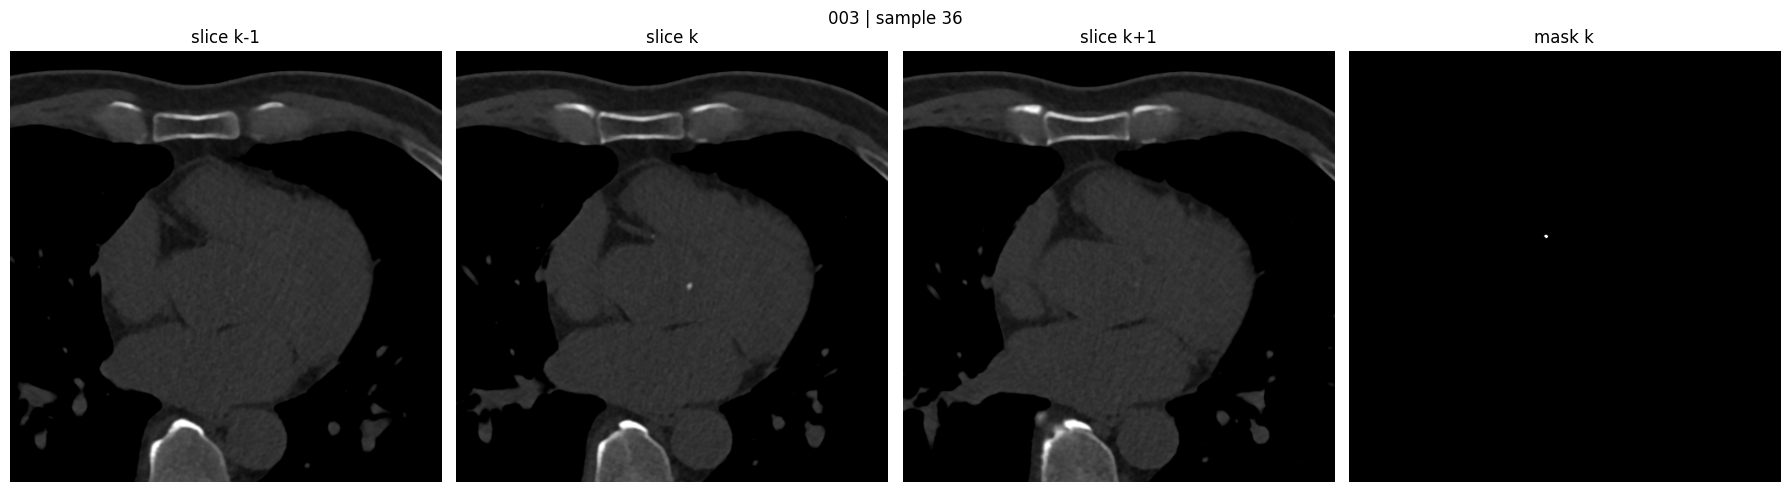

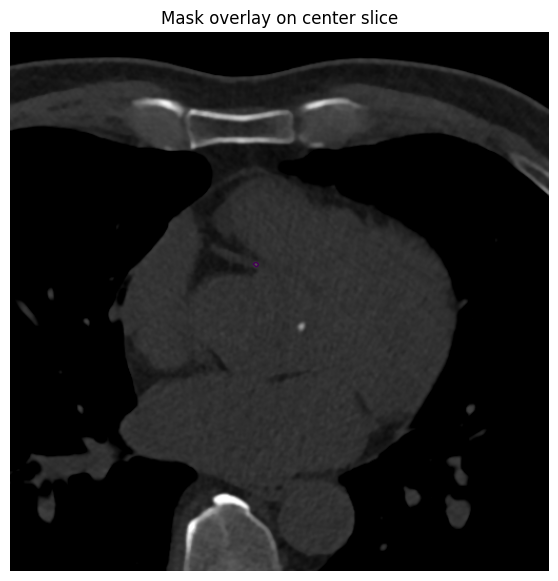

In [69]:
def load_positive_sample(case_id: str):
    row = manifest_df[manifest_df["case_id"] == case_id].iloc[0]
    x = np.load(row["input_path"], mmap_mode="r")
    y = np.load(row["mask_path"], mmap_mode="r")

    positive_idx = np.where(np.sum(y > 0, axis=(1, 2, 3)) > 0)[0]
    if len(positive_idx) == 0:
        return None
    
    idx = int(positive_idx[0])
    return np.array(x[idx]), np.array(y[idx]), idx

positive_cases = case_stats_df[case_stats_df["positive_samples"] > 0]["case_id"].tolist()
assert positive_cases, "No positive_masks found."

case_id = positive_cases[0]
x_sample, y_sample, sample_idx = load_positive_sample(case_id)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, title in enumerate(["slice k-1", "slice k", "slice k+1"]):
    axes[i].imshow(x_sample[i], cmap="gray")
    axes[i].set_title(title)
    axes[i].axis("off")

axes[3].imshow(y_sample[0], cmap="gray")
axes[3].set_title("mask k")
axes[3].axis("off")
plt.suptitle(f"{case_id} | sample {sample_idx}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(x_sample[1], cmap="gray")
if y_sample[0].max() > 0:
    plt.contour(y_sample[0], levels=[0.5], linewidths=1)
plt.title("Mask overlay on center slice")
plt.axis("off")
plt.show()

## Flatten case-level `.npy` arrays into sample-level index

In [46]:
def build_sample_index(manifest_subset: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in manifest_subset.iterrows():
        x = np.load(row["input_path"], mmap_mode="r")
        y = np.load(row["mask_path"], mmap_mode="r")
        positive = np.sum(y > 0, axis=(1,2,3)) > 0

        for sample_idx in range(x.shape[0]):
            rows.append({
                "case_id": row["case_id"],
                "split": row["split"],
                "input_path": row["input_path"],
                "mask_path": row["mask_path"],
                "sample_idx": sample_idx,
                "has_cac": int(positive[sample_idx]),
            })

    return pd.DataFrame(rows)

train_index_df = build_sample_index(manifest_df[manifest_df["split"] == "train"])
val_index_df = build_sample_index(manifest_df[manifest_df["split"] == "val"])
test_index_df = build_sample_index(manifest_df[manifest_df["split"] == "test"])

print("Train:", len(train_index_df))
print("Val:", len(val_index_df))
print("Test:", len(test_index_df))
print("\nTrain label ratio:")
print(train_index_df["has_cac"].value_counts(normalize=True))

Train: 16044
Val: 3322
Test: 3626

Train label ratio:
has_cac
0    0.842184
1    0.157816
Name: proportion, dtype: float64


## PyTorch Dataset

In [70]:
class SegmentationDataset(Dataset):
    def __init__(self, index_df: pd.DataFrame):
        self.index_df = index_df.reset_index(drop=True)
        self._input_cache = {}
        self._mask_cache = {}

    def __len__(self):
        return len(self.index_df)

    def _load_case(self, input_path: str, mask_path: str):
        if input_path not in self._input_cache:
            self._input_cache[input_path] = np.load(input_path, mmap_mode="r")
        if mask_path not in self._mask_cache:
            self._mask_cache[mask_path] = np.load(mask_path, mmap_mode="r")
        return self._input_cache[input_path], self._mask_cache[mask_path]

    def __getitem__(self, idx):
        row = self.index_df.iloc[idx]
        x_case, y_case = self._load_case(row["input_path"], row["mask_path"])

        x = np.array(x_case[int(row["sample_idx"])], dtype=np.float32)
        y = np.array(y_case[int(row["sample_idx"])], dtype=np.float32)
        y = (y > 0).astype(np.float32)

        return {
            "image": torch.from_numpy(x),
            "mask": torch.from_numpy(y),
            "case_id": row["case_id"],
            "sample_idx": int(row["sample_idx"]),
            "has_cac": int(row["has_cac"]),
        }

train_ds = SegmentationDataset(train_index_df)
val_ds = SegmentationDataset(val_index_df)
test_ds = SegmentationDataset(test_index_df)

print(len(train_ds), len(val_ds), len(test_ds))


16044 3322 3626


## Weighted sampler for lack of positive masks

Use this for **training only**. Validation/test remain naturally distributed.


In [71]:
def make_weighted_sampler(index_df: pd.DataFrame, positive_weight: float = 5.0):
    weights = np.where(index_df["has_cac"].values == 1, positive_weight, 1.0).astype(np.float64)
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights),
        num_samples=len(weights),
        replacement=True,
    )

train_sampler = make_weighted_sampler(train_index_df, positive_weight=4.0)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

batch = next(iter(train_loader))
print("Images:", batch["image"].shape)
print("Masks:", batch["mask"].shape)
print("Positive masks in sampled batch:", batch["has_cac"].sum().item())


Images: torch.Size([8, 3, 512, 512])
Masks: torch.Size([8, 1, 512, 512])
Positive masks in sampled batch: 2


# Model section

Replace the placeholder with your real architecture.

Model contract:

```text
Input  : [B, 3, H, W]
Output : [B, 1, H, W] logits
```

Do **not** apply sigmoid inside the model. Use logits for `BCEWithLogitsLoss`.


In [74]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.block(x)

# Downsampling block
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)
    
# Upsampling block
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        # In case of minor shape mismatch due to odd dimensions
        if x.shape[-2:] != skip.shape[-2:]:
            x = nn.functional.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x
    
# 2.5D U-Net
class UNetModel(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=16
    ):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_channels)              # 32
        self.enc2 = DownBlock(base_channels, base_channels * 2)          # 64
        self.enc3 = DownBlock(base_channels * 2, base_channels * 4)      # 128
        self.enc4 = DownBlock(base_channels * 4, base_channels * 8)      # 256

        # Bottleneck
        self.bottleneck = DownBlock(
            base_channels * 8,
            base_channels * 16
        )                                                                 # 512

        # Decoder
        self.up4 = UpBlock(
            in_channels=base_channels * 16,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 8
        )

        self.up3 = UpBlock(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 4
        )

        self.up2 = UpBlock(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 2,
            out_channels=base_channels * 2
        )

        self.up1 = UpBlock(
            in_channels=base_channels * 2,
            skip_channels=base_channels,
            out_channels=base_channels
        )

        # Final segmentation head
        self.out_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)       # [B, 32, H, W]
        s2 = self.enc2(s1)      # [B, 64, H/2, W/2]
        s3 = self.enc3(s2)      # [B, 128, H/4, W/4]
        s4 = self.enc4(s3)      # [B, 256, H/8, W/8]

        # Bottleneck
        b = self.bottleneck(s4) # [B, 512, H/16, W/16]

        # Decoder
        d4 = self.up4(b, s4)
        d3 = self.up3(d4, s3)
        d2 = self.up2(d3, s2)
        d1 = self.up1(d2, s1)

        # Output logits
        logits = self.out_conv(d1)
        return logits
    
model = UNetModel(
    in_channels=3,
    out_channels=1,
    base_channels=32
).to(DEVICE)

if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

batch = next(iter(train_loader))

x = batch["image"].to(DEVICE)
logits = model(x)

print("Input shape:", x.shape)
print("Output shape:", logits.shape)

Input shape: torch.Size([8, 3, 512, 512])
Output shape: torch.Size([8, 1, 512, 512])


## Loss functions

Baseline: **Dice + BCEWithLogitsLoss**.
AMP uses `autocast` for the forward/loss computation and `GradScaler` to keep FP16 gradients numerically stable.

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()
        dims = (1, 2, 3)

        intersection = torch.sum(probs * targets, dims)
        denominator = torch.sum(probs, dims) + torch.sum(targets, dims)
        dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
        return 1 - dice.mean()

class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        return self.dice_weight * self.dice(logits, targets) + self.bce_weight * self.bce(logits, targets)

criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
# Using AMP 
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

## segmentation metrics

Implemented:
- Dice
- IoU
- Precision
- Recall
- Focal Tversky Loss

Add later:
- HD95
- lesion-level sensitivity

In [76]:
def compute_metrics(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = targets.float()

    dims = (1, 2, 3)
    tp = torch.sum(preds * targets, dims)
    fp = torch.sum(preds * (1 - targets), dims)
    fn = torch.sum((1 - preds) * targets, dims)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = torch.where(
        (tp + fp) > 0,
        tp / (tp + fp + eps),
        torch.zeros_like(tp)
    )
    
    recall = torch.where(
        (tp + fn) > 0,
        tp / (tp + fn + eps),
        torch.zeros_like(tp)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
    }


## Positive / Negative-separated evaluation

In [77]:
@torch.no_grad()
def evaluate_pos_neg(
    model,
    loader,
    device,
    threshold=0.5,
    eps=1e-6
):
    model.eval()

    pos_dice = []
    pos_precision = []
    pos_recall = []

    neg_fp_pixels = []
    neg_pred_positive_samples = 0
    neg_total_samples = 0

    for batch in tqdm(loader, desc="Pos/Neg eval", leave=False):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(y.size(0)):
            gt = y[i]
            pred = preds[i]

            gt_has_cac = gt.sum() > 0

            tp = (pred * gt).sum()
            fp = (pred * (1 - gt)).sum()
            fn = ((1 - pred) * gt).sum()

            if gt_has_cac:
                dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
                if (tp + fp) > 0:
                    precision = tp / (tp + fp)
                else:
                    precision = torch.tensor(0.0, device=device)
                recall = (tp + eps) / (tp + fn + eps)

                pos_dice.append(dice.item())
                pos_precision.append(precision.item())
                pos_recall.append(recall.item())

            else:
                neg_total_samples += 1
                neg_fp_pixels.append(fp.item())

                if pred.sum() > 0:
                    neg_pred_positive_samples += 1

    return {
        "positive_slice_dice": float(np.mean(pos_dice)) if pos_dice else None,
        "positive_slice_precision": float(np.mean(pos_precision)) if pos_precision else None,
        "positive_slice_recall": float(np.mean(pos_recall)) if pos_recall else None,

        "negative_slice_mean_fp_pixels": float(np.mean(neg_fp_pixels)) if neg_fp_pixels else None,
        "negative_slice_fp_sample_rate": (
            neg_pred_positive_samples / neg_total_samples
            if neg_total_samples > 0 else None
        ),

        "num_positive_slices": len(pos_dice),
        "num_negative_slices": neg_total_samples,
    }

## Train/validation loop skeleton

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    metrics_store = {"dice": [], "iou": [], "precision": [], "recall": []}

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * x.size(0)

        metrics = compute_metrics(logits.detach(), y, threshold=cfg.MASK_THRESHOLD)

        for k, v in metrics.items():
            metrics_store[k].append(v)

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = {k: float(np.mean(v)) for k, v in metrics_store.items()}
    return epoch_loss, epoch_metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=cfg.MASK_THRESHOLD, eps=1e-6):
    model.eval()
    running_loss = 0.0
    
    # Storing the metrics of full epoch, both neg and pos slices.
    full_metrics = {"dice": [], "iou": [], "precision": [], "recall": []}

    # Storing the metrics of positive slices only
    pos_metrics = {"pos_dice": [], "pos_precision": [], "pos_recall": []}

    # Negative slice false positives
    neg_false_metrics = {"neg_fp_pixels": [], "neg_pred_positive_samples": 0, "neg_total_samples": 0}

    pbar = tqdm(loader, desc="Validation", leave=False)

    for batch in pbar:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)
        
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = model(x)
            loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(y.size(0)):
            gt = y[i]
            pred = preds[i]

            tp = (pred * gt).sum()
            fp = (pred * (1 - gt)).sum()
            fn = ((1 - pred) * gt).sum()

            # ------------------
            # All-slice metrics
            # ------------------
            dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
            iou = (tp + eps) / (tp + fp + fn + eps)

            if (tp + fp) > 0:
                precision = tp / (tp + fp + eps)
            else:
                precision = torch.tensor(0.0, device=device)
            
            if (tp + fn) > 0:
                recall = tp / (tp + fn + eps)
            else:
                recall = torch.tensor(0.0, device=device)
            
            full_metrics["dice"].append(dice.item())
            full_metrics["iou"].append(iou.item())
            full_metrics["precision"].append(precision.item())
            full_metrics["recall"].append(recall.item())

            # ------------------
            # Pos / Neg split
            # ------------------
            gt_has_cac = gt.sum() > 0

            if gt_has_cac:
                pos_metrics["pos_dice"].append(dice.item())
                pos_metrics["pos_precision"].append(precision.item())
                pos_metrics["pos_recall"].append(recall.item())
            else:
                neg_false_metrics["neg_total_samples"] += 1
                neg_false_metrics["neg_fp_pixels"].append(fp.item())
                if pred.sum() > 0:
                    neg_false_metrics["neg_pred_positive_samples"] += 1
                
        pbar.set_postfix(loss=f"{loss.item():4f}")
    
    all_metrics = {
            "dice": float(np.mean(full_metrics["dice"])),
            "iou": float(np.mean(full_metrics["iou"])),
            "precision": float(np.mean(full_metrics["precision"])),
            "recall": float(np.mean(full_metrics["recall"]))
        }
    separated_metrics = {
        "positive_slice_dice": float(np.mean(pos_metrics["pos_dice"])) if pos_metrics["pos_dice"] else None,
        "positive_slice_precision": float(np.mean(pos_metrics["pos_precision"])) if pos_metrics["pos_precision"] else None,
        "positive_slice_recall": float(np.mean(pos_metrics["pos_recall"])) if pos_metrics["pos_recall"] else None,

        "negative_slice_mean_fp_pixels": (
            float(np.mean(neg_false_metrics["neg_fp_pixels"])) if neg_false_metrics["neg_fp_pixels"] else None
        ),

        "negative_slice_fp_sample_rate": (
            neg_false_metrics["neg_pred_positive_samples"] / neg_false_metrics["neg_total_samples"]
            if neg_false_metrics["neg_total_samples"] > 0 else None
        ),

        "num_positive_slices": len(pos_metrics["pos_dice"]),
        "num_negative_slices": neg_false_metrics["neg_total_samples"],
    }

    val_loss = running_loss / len(loader.dataset)
    return val_loss, all_metrics, separated_metrics

## Sanity time taken

In [83]:
import time

model.train()
start = time.time()

num_test_batches = 20

for batch_idx, batch in enumerate(train_loader):
    if batch_idx >= num_test_batches:
        break

    x = batch["image"].to(DEVICE, non_blocking=True)
    y = batch["mask"].to(DEVICE, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

elapsed = time.time() - start
sec_per_batch = elapsed / num_test_batches

print(f"Seconds per training batch: {sec_per_batch:.3f}")
print(f"Estimated training-only epoch time: {sec_per_batch * len(train_loader) / 60:.1f} minutes")

Seconds per training batch: 1.176
Estimated training-only epoch time: 39.3 minutes


## Train + Validate

In [84]:
history = []
best_val_pos_dice = -1.0
best_model_path = "best_model.pt"

for epoch in range(1, cfg.EPOCHS + 1):
    start = time.time()

    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_loss, val_metrics, val_sep_metrics = validate_one_epoch(model, val_loader, criterion, DEVICE)

    elapsed = time.time() - start

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_dice": train_metrics["dice"],
        "val_dice": val_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_iou": val_metrics["iou"],
        "train_precision": train_metrics["precision"],
        "val_precision_all": val_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "val_recall_all": val_metrics["recall"],

        "val_pos_dice": val_sep_metrics["positive_slice_dice"],
        "val_pos_precision": val_sep_metrics["positive_slice_precision"],
        "val_pos_recall": val_sep_metrics["positive_slice_recall"],
        "val_neg_fp_rate": val_sep_metrics["negative_slice_fp_sample_rate"],
        "val_neg_mean_fp_pixels": val_sep_metrics["negative_slice_mean_fp_pixels"],
        "seconds": elapsed,
    }
    history.append(row)

    # Go for the validation for slices that have CAC
    best_val = val_sep_metrics["positive_slice_dice"]

    if best_val is not None and best_val > best_val_pos_dice:
        best_val_pos_dice = best_val
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_dice={train_metrics['dice']:.4f} | val_dice={val_metrics['dice']:.4f} | "
        f"val_precision={val_metrics['precision']:.4f} | val_recall={val_metrics['recall']:.4f} | "
        f"val_dice={val_metrics['dice']:.4f} | "
        f"pos_dice={fmt(val_sep_metrics['positive_slice_dice'])} | "
        f"pos_recall={val_sep_metrics['positive_slice_recall']:.4f} | "
        f"neg_fp_rate={val_sep_metrics['negative_slice_fp_sample_rate']:.4f} | "
        f"{elapsed:.1f}s"
    )

history_df = pd.DataFrame(history)
history_df.tail()

Training:   0%|          | 0/2006 [00:00<?, ?it/s]

Validation:   0%|          | 0/416 [00:00<?, ?it/s]

Epoch 01/4 | train_loss=0.5913 | val_loss=0.5294 | train_dice=0.5024 | val_dice=0.5902 | val_precision=0.0773 | val_recall=0.1532 | val_dice=0.5902 | pos_dice=0.5848 | pos_recall=0.9172 | neg_fp_rate=0.4087 | 2824.2s


Training:   0%|          | 0/2006 [00:00<?, ?it/s]

Validation:   0%|          | 0/416 [00:00<?, ?it/s]

...

Epoch 03/4 | train_loss=0.3889 | val_loss=0.4316 | train_dice=0.7531 | val_dice=0.8944 | val_precision=0.1548 | val_recall=0.1499 | val_dice=0.8944 | pos_dice=0.9016 | pos_recall=0.8970 | neg_fp_rate=0.1070 | 2851.8s


Training:   0%|          | 0/2006 [00:00<?, ?it/s]

Validation:   0%|          | 0/416 [00:00<?, ?it/s]

Epoch 04/4 | train_loss=0.3195 | val_loss=0.4256 | train_dice=0.8334 | val_dice=0.8587 | val_precision=0.1488 | val_recall=0.1589 | val_dice=0.8587 | pos_dice=0.9054 | pos_recall=0.9509 | neg_fp_rate=0.1507 | 2856.1s


,epoch,train_loss,val_loss,train_dice,val_dice,train_iou,val_iou,train_precision,val_precision_all,train_recall,val_recall_all,val_pos_dice,val_pos_precision,val_pos_recall,val_neg_fp_rate,val_neg_mean_fp_pixels,seconds
0,1,0.591283,0.529360,0.502374,0.590170,0.496385,0.566150,0.028260,0.077290,0.034655,0.153227,0.584768,0.462625,0.917156,0.408746,57.307192,2824.233220
1,2,0.502247,0.493439,0.624513,0.511319,0.571089,0.491701,0.244015,0.095673,0.399749,0.164669,0.685767,0.572657,0.985642,0.523672,125.303939,2842.406289
2,3,0.388885,0.431575,0.753134,0.894450,0.716720,0.884765,0.338168,0.154828,0.402630,0.149861,0.901554,0.926734,0.897003,0.106975,3.936032,2851.826498
3,4,0.319458,0.425600,0.833353,0.858675,0.807523,0.850225,0.373625,0.148791,0.389171,0.158864,0.905438,0.890601,0.950897,0.150705,8.603542,2856.099984


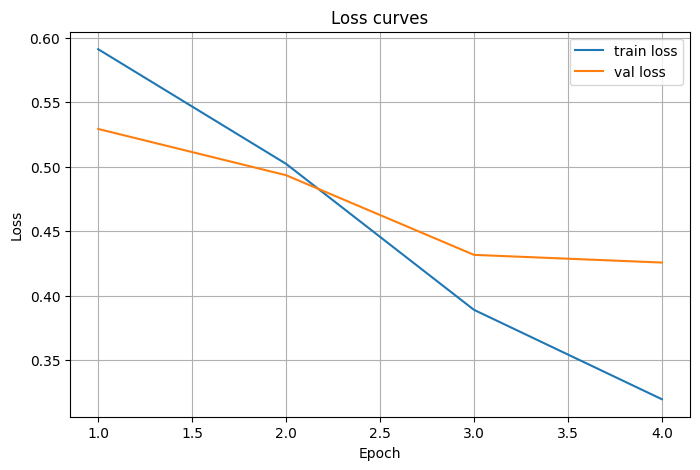

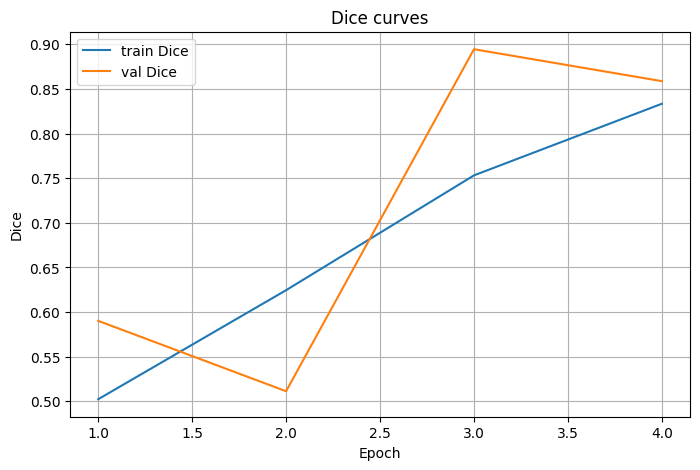

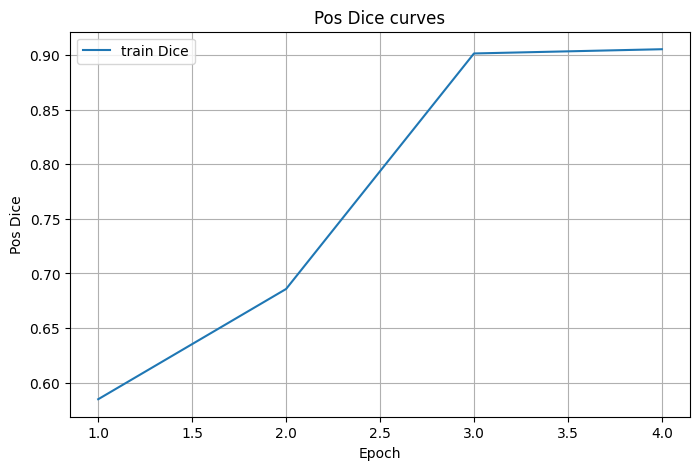

In [85]:
if len(history_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_dice"], label="train Dice")
    plt.plot(history_df["epoch"], history_df["val_dice"], label="val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Dice curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_pos_dice"], label="train Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Pos Dice")
    plt.title("Pos Dice curves")
    plt.legend()
    plt.grid(True)
    plt.show()

## Test evaluation

Only run this after architecture decisions are finalized.


In [86]:
if Path(best_model_path).exists():
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    test_loss, test_metrics, test_sep_metrics = validate_one_epoch(model, test_loader, criterion, DEVICE)
    
    print("Test loss:", round(test_loss, 4))
    print("Test metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")
    print("Test positive/negative-separated metrics:")
    for k, v in test_sep_metrics.items():
        print(f"{k}: {v}")
else:
    print("No trained checkpoint found.")


Validation:   0%|          | 0/454 [00:00<?, ?it/s]

Test loss: 0.4372
Test metrics:
dice: 0.8159
iou: 0.8086
precision: 0.1282
recall: 0.1323
Test positive/negative-separated metrics:
positive_slice_dice: 0.8148552657912905
positive_slice_precision: 0.8144085586018821
positive_slice_recall: 0.8400547260845866
negative_slice_mean_fp_pixels: 20.82454991816694
negative_slice_fp_sample_rate: 0.1839607201309329
num_positive_slices: 571
num_negative_slices: 3055


## Qualitative prediction display

Inspect false positives and false negatives. A metric without visual review is not enough in medical segmentation.

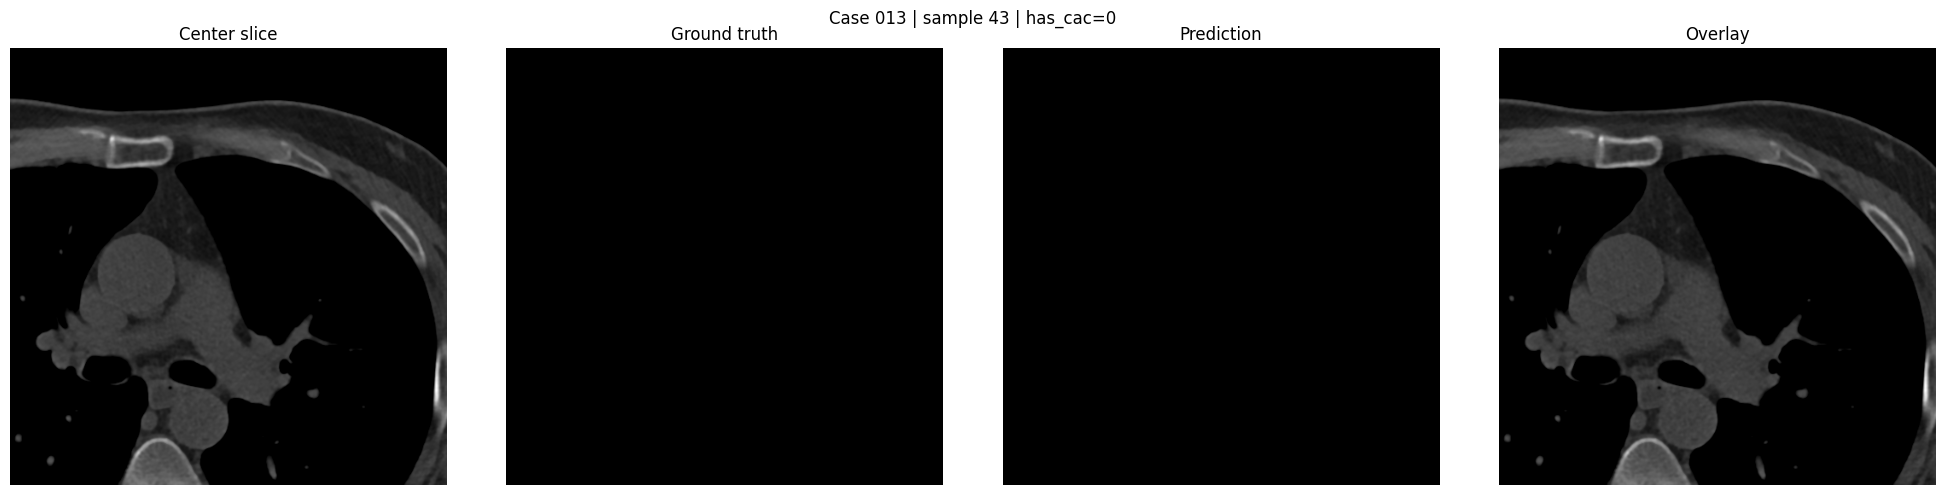

In [93]:
@torch.no_grad()
def visualize_prediction(model, dataset, idx=0, threshold=0.5):
    model.eval()
    item = dataset[idx]

    x = item["image"].unsqueeze(0).to(DEVICE)
    gt = item["mask"][0].cpu().numpy()

    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred = (prob >= threshold).astype(np.float32)

    center = item["image"][1].cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(center, cmap="gray")
    axes[0].set_title("Center slice")
    axes[0].axis("off")

    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    axes[3].imshow(center, cmap="gray")
    if gt.max() > 0:
        axes[3].contour(gt, levels=[0.5], linewidths=1)
    if pred.max() > 0:
        axes[3].contour(pred, levels=[0.5], linewidths=1)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.suptitle(f"Case {item['case_id']} | sample {item['sample_idx']} | has_cac={item['has_cac']}")
    plt.tight_layout()
    plt.show()

# Run after training:
visualize_prediction(model, test_ds, idx=100, threshold=cfg.MASK_THRESHOLD)


# Summary

Creating a baseline U-Net
Later add more techniques like Residual + dilated bottleneck variant, HD95 metric, Lesion-level sensitivity